# Spatial Omics Analysis Tutorial
This notebook demonstrates spatial transcriptomics analysis using Scanpy, Squidpy, and interactive visualizations.

Features:
- Load example Visium dataset
- Preprocessing and normalization (Seurat v3 flavor)
- PCA, neighbors, UMAP, and Leiden clustering
- Static spatial plots
- Interactive plots with Plotly and Napari

## 0. (Optional) Load Your Own Dataset
Instead of the built-in demo, you can load your own spatial omics data.

### Option A: Load a 10X Visium dataset
1. Download from [10X Genomics Datasets](https://www.10xgenomics.com/resources/datasets).\n2. Extract files (e.g., `filtered_feature_bc_matrix.h5` and `spatial/` folder).\n3. Load with Scanpy:
```python
import scanpy as sc
adata = sc.read_visium("data/Visium_BreastCancer/")
print(adata)
```

### Option B: Load a GEO dataset
If the authors provide `.h5ad` or `.mtx` files, load directly:
```python
adata = sc.read_h5ad("GSE123456_sample.h5ad")
# or MTX format
adata = sc.read_10x_mtx("path/to/mtx_folder/", var_names="gene_symbols")
```

### Option C: Convert a CSV matrix to AnnData
```python
import pandas as pd
from anndata import AnnData
df = pd.read_csv("counts_matrix.csv", index_col=0)
adata = AnnData(df.T)  # spots = rows, genes = cols
adata.var_names = df.index
adata.obs_names = df.columns
print(adata)
```

👉 For beginners, we recommend starting with 10X Visium datasets and using `sc.read_visium(path)`.

In [ ]:
# Install dependencies (run once)
#!pip install scanpy squidpy plotly napari[all] scikit-image anndata matplotlib pandas

In [1]:
# Import libraries
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sc.settings.verbosity = 3
sc.logging.print_versions()

/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap 

Package,Version
scanpy,1.11.4
squidpy,1.6.5
matplotlib,3.10.6
pandas,2.3.2
numpy,2.2.6
Component,Info
Python,"3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]"
OS,macOS-15.6.1-x86_64-i386-64bit-Mach-O
CPU,"8 logical CPU cores, i386"
GPU,No GPU found


## 1️⃣ Load Example Dataset
We will use the 10x Genomics Visium mouse brain dataset as an example.

In [2]:
# Download and load the dataset
adata = sq.datasets.visium_hne_adata()
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 2️⃣ Preprocessing
Normalize, log-transform, select highly variable genes (Seurat v3), scale.

In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 3️⃣ PCA, neighbors, UMAP, and clustering

In [4]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)
running Leiden clustering


/var/folders/9m/7gl0jq895tzg223m3x_1ly_00000gn/T/ipykernel_58402/2451136379.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


## 4️⃣ Visualize UMAP

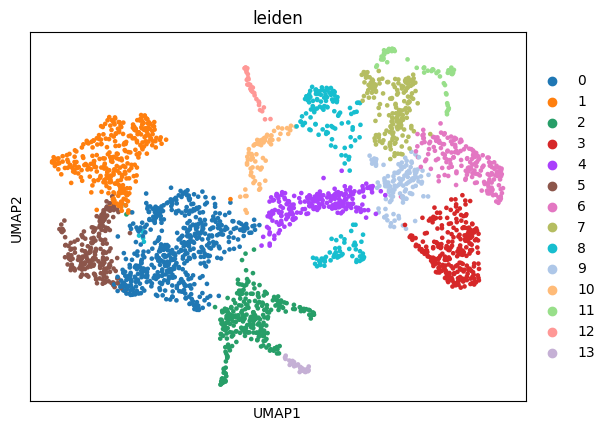

In [5]:
sc.pl.umap(adata, color=['leiden'])

## 5️⃣ Static Spatial Plots

/var/folders/9m/7gl0jq895tzg223m3x_1ly_00000gn/T/ipykernel_58402/1948757127.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=['leiden'], spot_size=1.5)


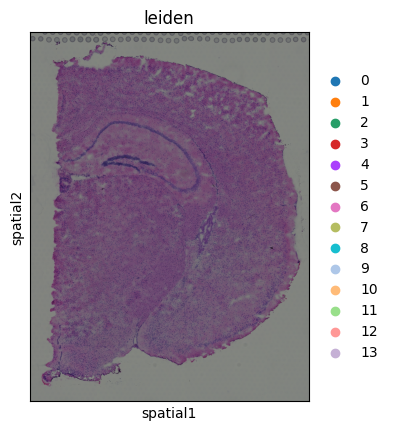

/var/folders/9m/7gl0jq895tzg223m3x_1ly_00000gn/T/ipykernel_58402/1948757127.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=['Tcea1'], spot_size=40)  # Example gene


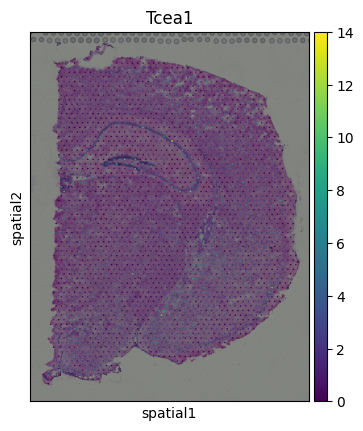

In [8]:
sc.pl.spatial(adata, color=['leiden'], spot_size=1.5)
sc.pl.spatial(adata, color=['Tcea1'], spot_size=40)  # Example gene

## 6️⃣ Neighborhood Graph & Enrichment (Optional)

In [9]:

print(adata.obs['leiden'].shape)  # should match n_obs
print(adata.obsm['spatial'].shape)  # should be (n_obs, 2)


(2688,)
(2688, 2)


In [10]:
print(adata.obsm.keys())
sq.gr.spatial_neighbors(adata, coord_type='generic')  # 'array' for Visium or 'generic'
print(adata.n_obs)  # total number of spots

KeysView(AxisArrays with keys: X_pca, X_umap, spatial)
Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
2688


Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden_spatial', the cluster labels (adata.obs, categorical) (0:00:00)
Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/pritam/Desktop/Spatial Omics/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap 

Adding `adata.uns['leiden_spatial_nhood_enrichment']`
Finish (0:00:15)


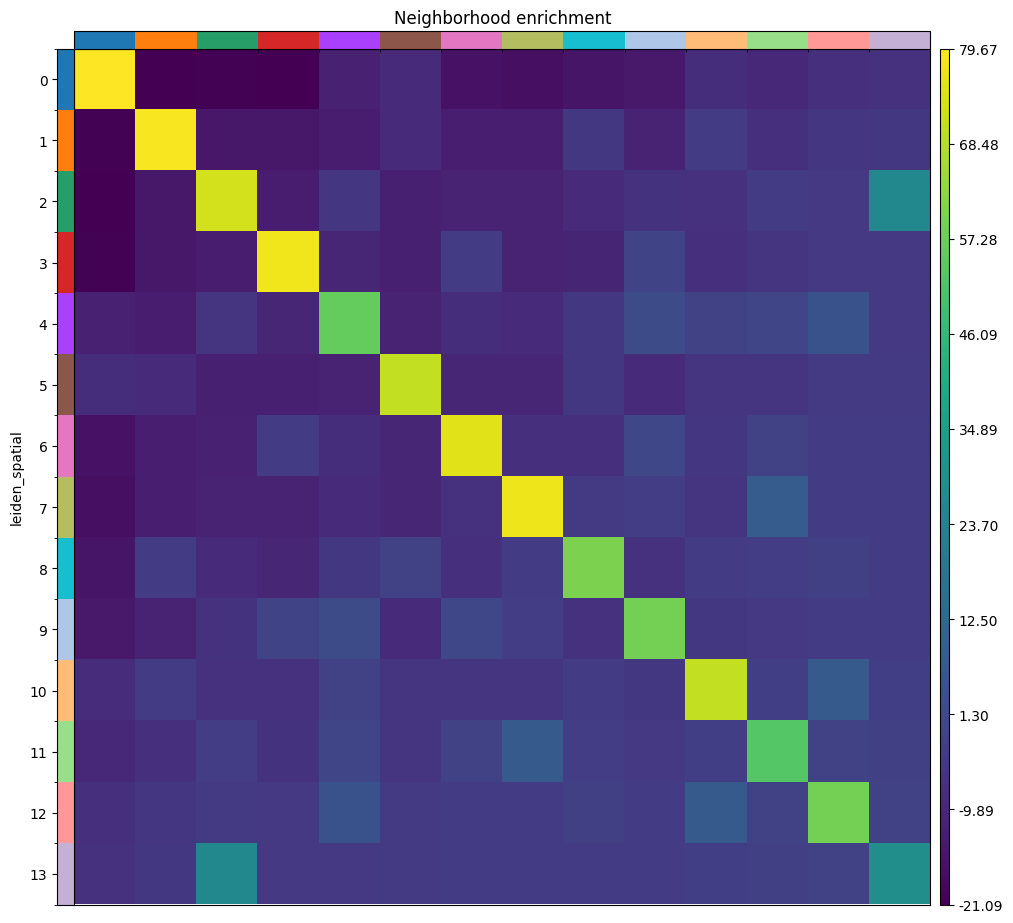

In [11]:
# 1. Recompute spatial neighbors
sq.gr.spatial_neighbors(adata, coord_type="generic")

# 2. Re-run Leiden on the spatial graph
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_spatial")
adata.obs['leiden_spatial'] = adata.obs['leiden_spatial'].astype("category")

# 3. Neighborhood enrichment
sq.gr.nhood_enrichment(adata, cluster_key="leiden_spatial")

# 4. Plot enrichment
sq.pl.nhood_enrichment(adata, cluster_key="leiden_spatial")



In [12]:
print("Total spots:", adata.n_obs)
print("Unique Leiden clusters:", adata.obs['leiden'].cat.categories)
print("Counts per cluster:\n", adata.obs['leiden'].value_counts())


Total spots: 2688
Unique Leiden clusters: Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13'],
      dtype='object')
Counts per cluster:
 leiden
0     540
1     323
2     282
3     256
4     223
5     220
6     180
7     175
8     169
9     130
10     70
11     58
12     32
13     30
Name: count, dtype: int64


In [13]:
print(adata.var_names[:20])   # first 20 genes
print(adata.var_names[-20:])  # last 20 genes


Index(['St18', '3110035E14Rik', 'Sulf1', 'Tfap2b', 'Gm29107', 'Ogfrl1',
       'Col9a1', 'Col19a1', 'Neurl3', 'Gm33533', '2010300C02Rik', 'Map4k4',
       'Gm29260', 'Pantr1', 'Gm28782', '1500015O10Rik', 'Col3a1', 'Slc39a10',
       'Tmeff2', 'Gm28322'],
      dtype='object')
Index(['Scd2', 'Scd1', 'Kcnip2', 'Psd', 'Ina', 'Neurl1a', 'Rpl13a-ps1',
       'Tcf7l2', 'mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb', 'Gm10931'],
      dtype='object')


## 7️⃣ Interactive Plot with Plotly

In [17]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"  # change to "notebook_connected" if needed

gene = "Col3a1"

spatial_df = pd.DataFrame({
    "x": adata.obsm["spatial"][:, 0],
    "y": adata.obsm["spatial"][:, 1],
    "cluster": adata.obs["leiden"].astype(str)
})

if gene in adata.var_names:
    gene_exp = adata[:, gene].X
    if hasattr(gene_exp, "toarray"):
        gene_exp = gene_exp.toarray().flatten()
    else:
        gene_exp = gene_exp.flatten()
    spatial_df[gene] = gene_exp

    if spatial_df[gene].sum() == 0:
        print(f"⚠️ Gene {gene} has no expression in this dataset. Showing clusters instead.")
        color_col = "cluster"
    else:
        color_col = gene
else:
    print(f"⚠️ Gene {gene} not found in dataset. Showing clusters instead.")
    color_col = "cluster"

fig = px.scatter(
    spatial_df, x="x", y="y",
    color=color_col,
    hover_data=["cluster", gene] if gene in spatial_df else ["cluster"],
    title=f"Spatial Expression: {gene} (Interactive)",
    width=700, height=600
)
fig.update_yaxes(autorange="reversed")
fig.show()


## 8️⃣ Interactive Visualization with Napari (Optional, Desktop)

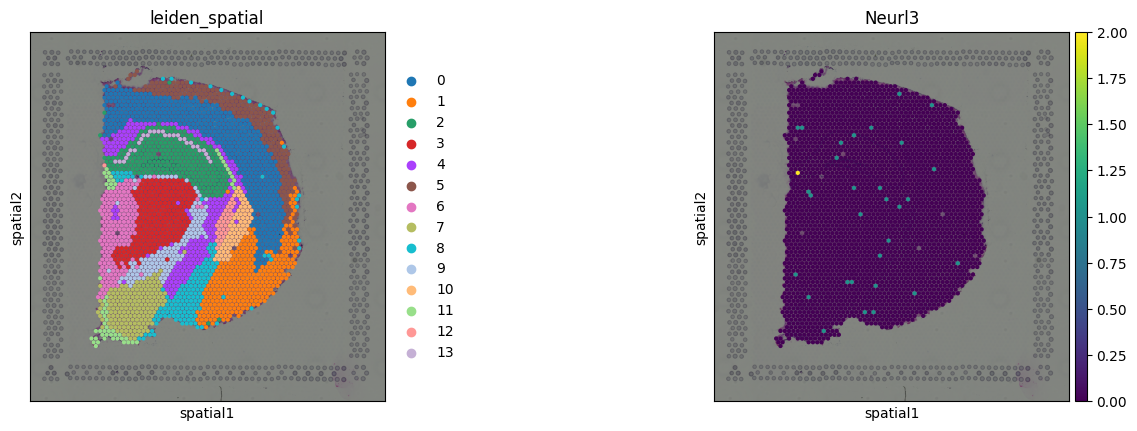

In [18]:
import squidpy as sq

# Plot clusters + gene expression side by side
sq.pl.spatial_scatter(
    adata,
    color=["leiden_spatial","Neurl3"],  # cluster & gene
    shape="circle",              # fix: set marker shape
    size=1.5, 
    cmap="viridis"
)


In [19]:
import numpy as np
import napari
import pandas as pd
import matplotlib.cm as cm

# Assume adata is already loaded with spatial coordinates and gene expression data
# (e.g., from scanpy or similar)

# Get spatial coordinates
coords = adata.obsm['spatial']
gene = "Neurl3"

# Check if the gene exists before proceeding
if gene not in adata.var_names:
    print(f"Gene {gene} not found in dataset.")
else:
    # Get gene expression values
    expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()

    # Get cluster IDs (as strings for categorical coloring)
    clusters = adata.obs['leiden'].astype('category').values

    # Create a features table for the points layer
    features = pd.DataFrame({'leiden_clusters': clusters, 'gene_expression': expr})

    # Get a list of unique cluster names
    unique_clusters = features['leiden_clusters'].unique()
    num_clusters = len(unique_clusters)

    # Generate a color cycle (a list of colors for each category)
    colors = cm.get_cmap('tab10', num_clusters)
    cluster_color_cycle = [colors(i) for i in range(num_clusters)]

    # Launch Napari viewer
    viewer = napari.Viewer()

    # Add points for gene expression, colored by the continuous expression value
    viewer.add_points(
        coords,
        name=f"{gene} expression",
        features=features,
        face_color='gene_expression',
        face_colormap='viridis',
        size=10,
        border_width=0 # <-- Corrected: Use border_width instead of edge_width
    )

    # Add a second Points layer for clusters, colored by the categorical cluster ID
    viewer.add_points(
        coords,
        name="Leiden clusters",
        features=features,
        face_color='leiden_clusters',
        face_color_cycle=cluster_color_cycle,
        size=10,
        border_width=0 # <-- Corrected: Use border_width instead of edge_width
    )

    # To improve visibility, you may want to set blending to 'additive'
    viewer.layers[f"{gene} expression"].blending = 'additive'
    viewer.layers["Leiden clusters"].blending = 'opaque'

    napari.run()

/var/folders/9m/7gl0jq895tzg223m3x_1ly_00000gn/T/ipykernel_58402/333877220.py:31: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
import numpy as np
import napari
import pandas as pd
import matplotlib.cm as cm

# Assume adata is already loaded with spatial coordinates and gene expression data
# (e.g., from scanpy or similar)

# Get spatial coordinates
coords = adata.obsm['spatial']
gene = "Neurl3"

# Check if the gene exists before proceeding
if gene not in adata.var_names:
    print(f"Gene {gene} not found in dataset.")
else:
    # Get gene expression values
    expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()

    # Get cluster IDs (as strings for categorical coloring)
    clusters = adata.obs['leiden'].astype('category').values

    # Get the unique gene names to use as labels
    gene_names = adata.var_names[adata.var_names == gene].tolist() * len(coords)

    # Create a features table for the points layer
    features = pd.DataFrame({
        'leiden_clusters': clusters,
        'gene_expression': expr,
        'gene_name': gene_names
    })

    # Get a list of unique cluster names
    unique_clusters = features['leiden_clusters'].unique()
    num_clusters = len(unique_clusters)

    # Generate a color cycle (a list of colors for each category)
    colors = cm.get_cmap('tab10', num_clusters)
    cluster_color_cycle = [colors(i) for i in range(num_clusters)]

    # Define the text properties dictionary
    text_parameters = {
        'string': 'Gene: {gene_name}',  # Use f-string-like syntax to get label from features table
        'size': 12,
        'color': 'black',
        'translation': [0, -10],  # Optional: Adjust text position relative to points
    }
    
    # Launch Napari viewer
    viewer = napari.Viewer()

    # Add points for gene expression, colored by the continuous expression value
    viewer.add_points(
        coords,
        name=f"{gene} expression",
        features=features,
        face_color='gene_expression',
        face_colormap='viridis',
        size=10,
        border_width=0,
        text=text_parameters # <-- Add the text parameter
    )

    # Add a second Points layer for clusters, colored by the categorical cluster ID
    viewer.add_points(
        coords,
        name="Leiden clusters",
        features=features,
        face_color='leiden_clusters',
        face_color_cycle=cluster_color_cycle,
        size=10,
        border_width=0
    )

    # To improve visibility, you may want to set blending to 'additive'
    viewer.layers[f"{gene} expression"].blending = 'additive'
    viewer.layers["Leiden clusters"].blending = 'opaque'

    napari.run()